In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_iris

df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


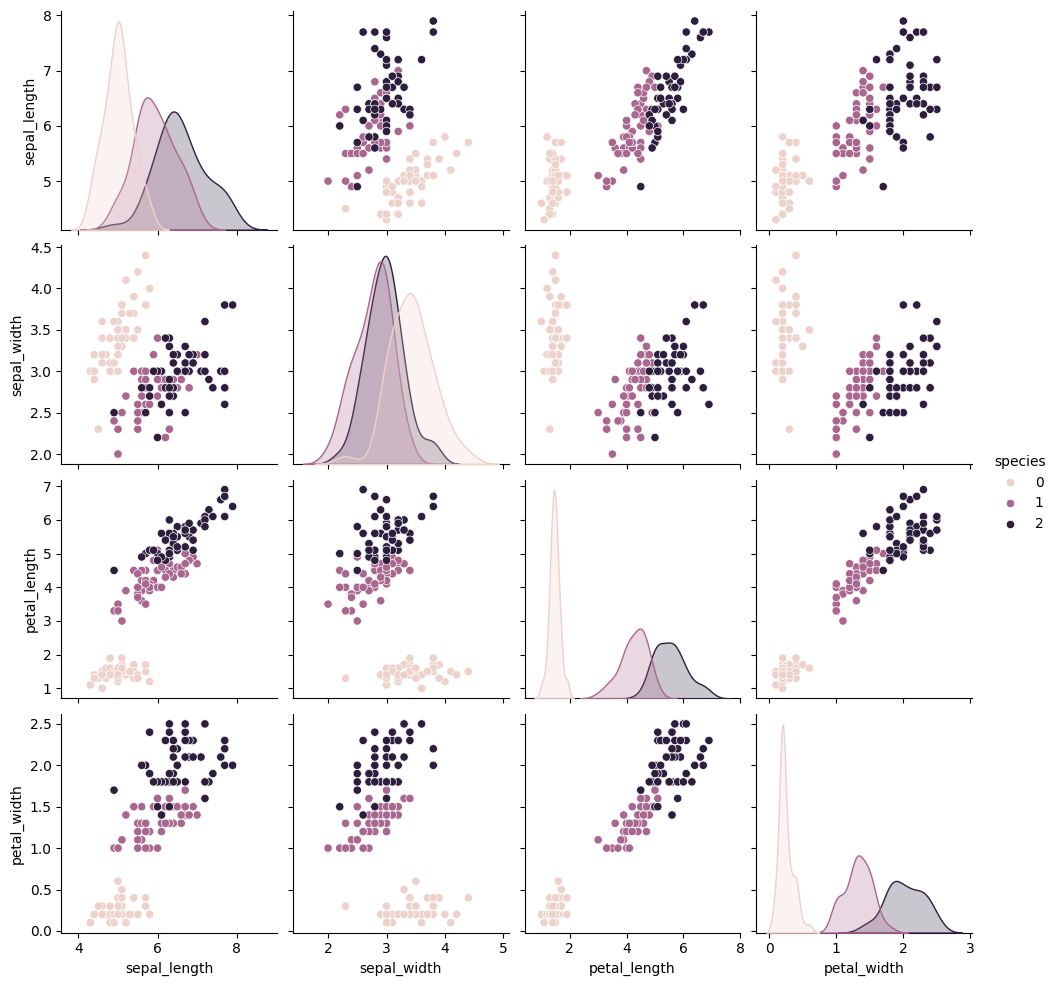

In [ ]:
sns.pairplot(df, hue='species')

In [ ]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [ ]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


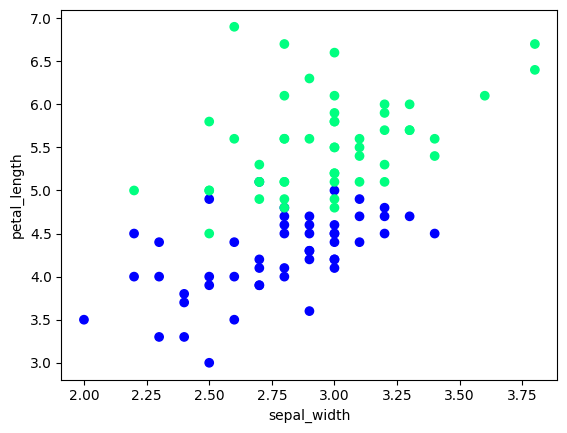

In [ ]:
plt.scatter(df['sepal_width'], df['petal_length'], c=df['species'],cmap='winter')
plt.xlabel('sepal_width')
plt.ylabel('petal_length')
plt.show()

In [ ]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [ ]:
df_train

,sepal_width,petal_length,species
90,2.6,4.4,1
110,3.2,5.1,2
77,3.0,5.0,1
127,3.0,4.9,2
94,2.7,4.2,1
65,3.1,4.4,1
108,2.5,5.8,2
120,3.2,5.7,2
53,2.3,4.0,1
63,2.9,4.7,1


In [ ]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

## Case 1 : Bagging

In [ ]:
# Data for Tree 1

df_bag = df_train.sample(8,replace = True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
77,3.0,5.0,1
94,2.7,4.2,1
90,2.6,4.4,1
63,2.9,4.7,1
120,3.2,5.7,2
94,2.7,4.2,1
65,3.1,4.4,1
110,3.2,5.1,2


In [ ]:
!pip install mlxtend

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [ ]:
dt_bag1 = DecisionTreeClassifier()

In [ ]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf,legend=2)
    y_pred = clf.predict(X_test)
    print('\n Accuracy Is :',accuracy_score(y_test,y_pred),'\n')

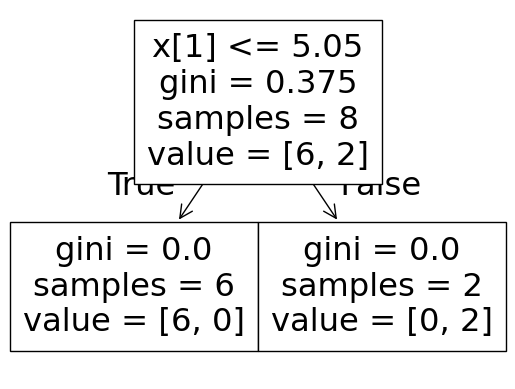


 Accuracy Is : 1.0 



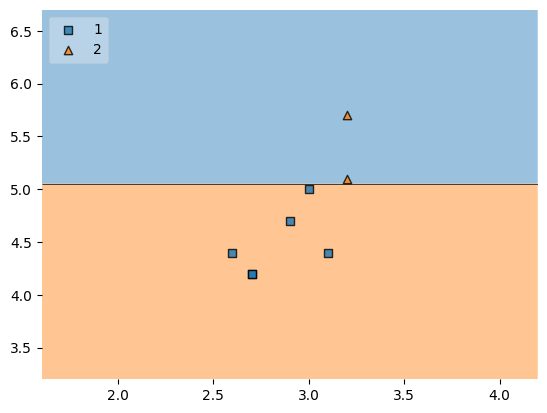

In [ ]:
evaluate(dt_bag1,X,y)

In [ ]:
# Data for Tree 2

df_bag = df_train.sample(8,replace = True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
94,2.7,4.2,1
90,2.6,4.4,1
94,2.7,4.2,1
108,2.5,5.8,2
120,3.2,5.7,2
120,3.2,5.7,2
110,3.2,5.1,2
94,2.7,4.2,1


In [ ]:
dt_bag2 = DecisionTreeClassifier()

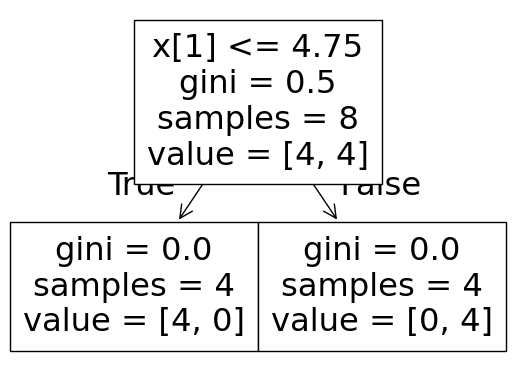


 Accuracy Is : 1.0 



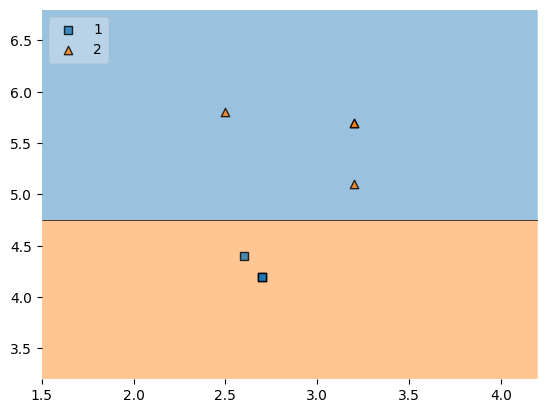

In [ ]:
evaluate(dt_bag2,X,y)


In [ ]:
# Data for Tree 3

df_bag = df_train.sample(8,replace = True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
65,3.1,4.4,1
108,2.5,5.8,2
94,2.7,4.2,1
94,2.7,4.2,1
65,3.1,4.4,1
77,3.0,5.0,1
90,2.6,4.4,1
90,2.6,4.4,1


In [ ]:
dt_bag3 = DecisionTreeClassifier()

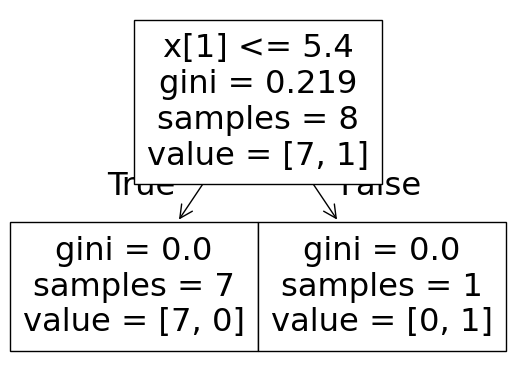


 Accuracy Is : 1.0 



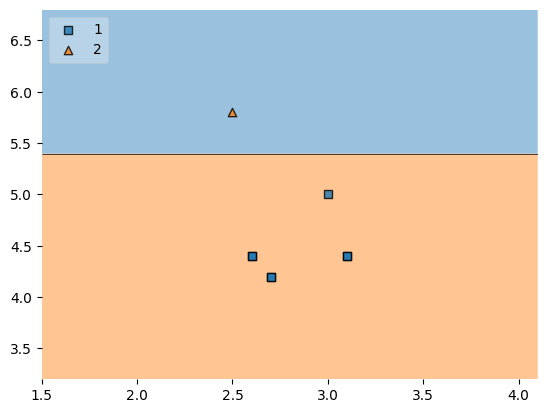

In [ ]:
evaluate(dt_bag3,X,y)


## Predict

In [ ]:
df_test

,sepal_width,petal_length,species
141,3.1,5.1,2
139,3.1,5.4,2
138,3.0,4.8,2
99,2.8,4.1,1
114,2.8,5.1,2


In [ ]:
print("Predictor 1 :",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2 :",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3 :",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 : [1]
Predictor 2 : [2]
Predictor 3 : [1]
